# Audio Analysis: Extracting Stress/Consistency Signals from Claim Narration

**Goal:** Extract acoustic features from each claim video's audio track, build a stress/consistency score, and validate it against the known ground-truth style labels (`calm` vs `distressed`) baked into your synthetic test set.

**Fully offline:** `librosa` runs entirely locally on the audio waveform — no API calls. Optional local Whisper transcription is also offline (runs the open-source model on-device, not the hosted API).

**Important framing (be upfront about this in your demo):** this is a **heuristic acoustic stress indicator**, not a validated clinical or forensic deception-detection system. Speech rate, pitch variance, and pause patterns correlate with arousal/stress in the psychology and speech-processing literature, but they are *not* reliable lie detectors on their own. Frame this as "a signal worth flagging for human review," not "proof of dishonesty." This distinction matters both ethically and for demo credibility.

## 1. Setup

In [2]:
!pip install librosa moviepy soundfile matplotlib pandas --quiet

In [3]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
# pip install librosa moviepy soundfile matplotlib pandas --quiet
# pip install openai-whisper --quiet   # optional, only if you want transcription too

import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
from moviepy.editor import VideoFileClip

VIDEOS_WITH_AUDIO_DIR = '/kaggle/input/datasets/ronak038/sample-audio-with-video'
MANIFEST_PATH = os.path.join(VIDEOS_WITH_AUDIO_DIR, 'ground_truth_manifest.json')
EXTRACTED_AUDIO_DIR = 'extracted_audio'
os.makedirs(EXTRACTED_AUDIO_DIR, exist_ok=True)

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f'Loaded manifest with {len(manifest)} videos.')
for name, info in manifest.items():
    print(f"  {name}: style={info.get('narration_style', 'unknown')}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
error: XDG_RUNTIME_DIR not set in the environment.


Loaded manifest with 26 videos.
  claim_single_dent_v1.mp4: style=distressed
  claim_single_dent_v2.mp4: style=distressed
  claim_single_scratch_v1.mp4: style=calm
  claim_single_scratch_v2.mp4: style=calm
  claim_single_crack_v1.mp4: style=distressed
  claim_single_crack_v2.mp4: style=calm
  claim_single_glass_shatter_v1.mp4: style=calm
  claim_single_glass_shatter_v2.mp4: style=distressed
  claim_single_lamp_broken_v1.mp4: style=distressed
  claim_single_lamp_broken_v2.mp4: style=calm
  claim_single_tire_flat_v1.mp4: style=distressed
  claim_single_tire_flat_v2.mp4: style=distressed
  claim_pair_dent_scratch.mp4: style=distressed
  claim_pair_crack_glass_shatter.mp4: style=distressed
  claim_pair_scratch_crack.mp4: style=calm
  claim_pair_dent_tire_flat.mp4: style=calm
  claim_pair_lamp_broken_scratch.mp4: style=calm
  claim_pair_dent_crack.mp4: style=distressed
  claim_mixed_1.mp4: style=calm
  claim_mixed_2.mp4: style=distressed
  claim_mixed_3.mp4: style=distressed
  claim_mixed_4

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No su

## 2. Extract Audio Track from Each Video

In [5]:
def extract_audio_from_video(video_path, output_wav_path):
    clip = VideoFileClip(video_path)
    clip.audio.write_audiofile(output_wav_path, fps=22050, verbose=False, logger=None)
    clip.close()
    return output_wav_path


for video_name, info in manifest.items():
    video_path = os.path.join(VIDEOS_WITH_AUDIO_DIR, video_name)
    wav_name = os.path.splitext(video_name)[0] + '_extracted.wav'
    wav_path = os.path.join(EXTRACTED_AUDIO_DIR, wav_name)

    extract_audio_from_video(video_path, wav_path)
    info['extracted_audio_path'] = wav_path
    print(f'Extracted: {wav_path}')

Extracted: extracted_audio/claim_single_dent_v1_extracted.wav
Extracted: extracted_audio/claim_single_dent_v2_extracted.wav
Extracted: extracted_audio/claim_single_scratch_v1_extracted.wav
Extracted: extracted_audio/claim_single_scratch_v2_extracted.wav
Extracted: extracted_audio/claim_single_crack_v1_extracted.wav
Extracted: extracted_audio/claim_single_crack_v2_extracted.wav
Extracted: extracted_audio/claim_single_glass_shatter_v1_extracted.wav
Extracted: extracted_audio/claim_single_glass_shatter_v2_extracted.wav
Extracted: extracted_audio/claim_single_lamp_broken_v1_extracted.wav
Extracted: extracted_audio/claim_single_lamp_broken_v2_extracted.wav
Extracted: extracted_audio/claim_single_tire_flat_v1_extracted.wav
Extracted: extracted_audio/claim_single_tire_flat_v2_extracted.wav
Extracted: extracted_audio/claim_pair_dent_scratch_extracted.wav
Extracted: extracted_audio/claim_pair_crack_glass_shatter_extracted.wav
Extracted: extracted_audio/claim_pair_scratch_crack_extracted.wav
Ext

## 3. Extract Acoustic Features with Librosa

Features chosen specifically because they're established correlates of speech rate and vocal arousal/stress in the speech-processing literature:

- **Pitch (F0) mean & variance** — stressed/aroused speech tends to show more pitch instability.
- **Speaking rate proxy (via tempo/onset density)** — faster, more clipped speech often correlates with urgency or nervousness.
- **Pause ratio** — fraction of the clip that's silence/near-silence; frequent short pauses can indicate hesitation.
- **RMS energy variance** — volume instability, another arousal-correlated signal.
- **Zero-crossing rate variance** — correlates with voice quality changes (breathiness, tension).

In [6]:
def extract_acoustic_features(wav_path, sr=22050):
    y, sr = librosa.load(wav_path, sr=sr)

    # Trim leading/trailing silence for cleaner measurement
    y_trimmed, _ = librosa.effects.trim(y, top_db=30)
    if len(y_trimmed) < sr * 0.3:  # fallback if trim was too aggressive on quiet audio
        y_trimmed = y

    duration_sec = len(y_trimmed) / sr

    # --- Pitch (F0) via pyin ---
    f0, voiced_flag, _ = librosa.pyin(
        y_trimmed, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr
    )
    f0_voiced = f0[voiced_flag] if voiced_flag is not None else np.array([])
    pitch_mean = float(np.nanmean(f0_voiced)) if len(f0_voiced) > 0 else 0.0
    pitch_std = float(np.nanstd(f0_voiced)) if len(f0_voiced) > 0 else 0.0

    # --- Speaking rate proxy: onset density (onsets per second) ---
    onset_env = librosa.onset.onset_strength(y=y_trimmed, sr=sr)
    onsets = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)
    onset_rate = len(onsets) / duration_sec if duration_sec > 0 else 0.0

    # --- Pause ratio: fraction of frames below an energy threshold ---
    rms = librosa.feature.rms(y=y_trimmed)[0]
    silence_threshold = np.percentile(rms, 20)  # bottom 20th percentile as a rough silence floor
    pause_ratio = float(np.mean(rms < silence_threshold))

    # --- RMS energy variance ---
    rms_std = float(np.std(rms))
    rms_mean = float(np.mean(rms))

    # --- Zero-crossing rate variance ---
    zcr = librosa.feature.zero_crossing_rate(y_trimmed)[0]
    zcr_std = float(np.std(zcr))

    return {
        'duration_sec': round(duration_sec, 2),
        'pitch_mean_hz': round(pitch_mean, 1),
        'pitch_std_hz': round(pitch_std, 1),
        'onset_rate_per_sec': round(onset_rate, 2),
        'pause_ratio': round(pause_ratio, 3),
        'rms_mean': round(rms_mean, 4),
        'rms_std': round(rms_std, 4),
        'zcr_std': round(zcr_std, 4)
    }

In [7]:
all_features = {}

for video_name, info in manifest.items():
    print(f'Extracting features: {video_name}...')
    features = extract_acoustic_features(info['extracted_audio_path'])
    all_features[video_name] = features
    info['acoustic_features'] = features

features_df = pd.DataFrame(all_features).T
features_df['narration_style'] = [manifest[v]['narration_style'] for v in features_df.index]
features_df

Extracting features: claim_single_dent_v1.mp4...
Extracting features: claim_single_dent_v2.mp4...
Extracting features: claim_single_scratch_v1.mp4...
Extracting features: claim_single_scratch_v2.mp4...
Extracting features: claim_single_crack_v1.mp4...
Extracting features: claim_single_crack_v2.mp4...
Extracting features: claim_single_glass_shatter_v1.mp4...
Extracting features: claim_single_glass_shatter_v2.mp4...
Extracting features: claim_single_lamp_broken_v1.mp4...
Extracting features: claim_single_lamp_broken_v2.mp4...
Extracting features: claim_single_tire_flat_v1.mp4...
Extracting features: claim_single_tire_flat_v2.mp4...
Extracting features: claim_pair_dent_scratch.mp4...
Extracting features: claim_pair_crack_glass_shatter.mp4...
Extracting features: claim_pair_scratch_crack.mp4...
Extracting features: claim_pair_dent_tire_flat.mp4...
Extracting features: claim_pair_lamp_broken_scratch.mp4...
Extracting features: claim_pair_dent_crack.mp4...
Extracting features: claim_mixed_1.

,duration_sec,pitch_mean_hz,pitch_std_hz,onset_rate_per_sec,pause_ratio,rms_mean,rms_std,zcr_std,narration_style
claim_single_dent_v1.mp4,8.06,96.1,12.9,5.09,0.201,0.0535,0.0271,0.0939,distressed
claim_single_dent_v2.mp4,7.83,97.0,12.6,5.24,0.201,0.0543,0.0274,0.0920,distressed
claim_single_scratch_v1.mp4,8.89,104.5,9.4,5.17,0.201,0.0502,0.0373,0.0957,calm
claim_single_scratch_v2.mp4,8.71,101.3,9.2,5.63,0.199,0.0484,0.0386,0.0869,calm
claim_single_crack_v1.mp4,8.93,96.1,13.1,6.27,0.200,0.0493,0.0298,0.0828,distressed
claim_single_crack_v2.mp4,8.98,100.7,9.1,5.57,0.202,0.0508,0.0385,0.0832,calm
claim_single_glass_shatter_v1.mp4,7.30,103.5,8.8,5.07,0.200,0.0491,0.0374,0.1314,calm
claim_single_glass_shatter_v2.mp4,7.67,99.0,11.2,6.65,0.199,0.0532,0.0286,0.0922,distressed
claim_single_lamp_broken_v1.mp4,7.07,99.8,8.0,6.65,0.200,0.0531,0.0278,0.1090,distressed
claim_single_lamp_broken_v2.mp4,9.00,104.2,9.8,5.78,0.201,0.0495,0.0373,0.0969,calm


## 4. Validate: Do Features Actually Separate Calm vs. Distressed?

This is the critical check — before trusting any derived "stress score," confirm the raw features themselves show a meaningful difference between your two known ground-truth styles. If they don't, the scoring logic downstream is meaningless.

In [8]:
comparison = features_df.groupby('narration_style')[
    ['pitch_std_hz', 'onset_rate_per_sec', 'pause_ratio', 'rms_std', 'zcr_std']
].mean()

print('Mean feature values by narration style (should differ meaningfully):')
comparison

Mean feature values by narration style (should differ meaningfully):


,pitch_std_hz,onset_rate_per_sec,pause_ratio,rms_std,zcr_std
narration_style,,,,,
calm,9.300000,5.737500,0.200333,0.038000,0.096017
distressed,11.728571,5.929286,0.200643,0.028186,0.092521


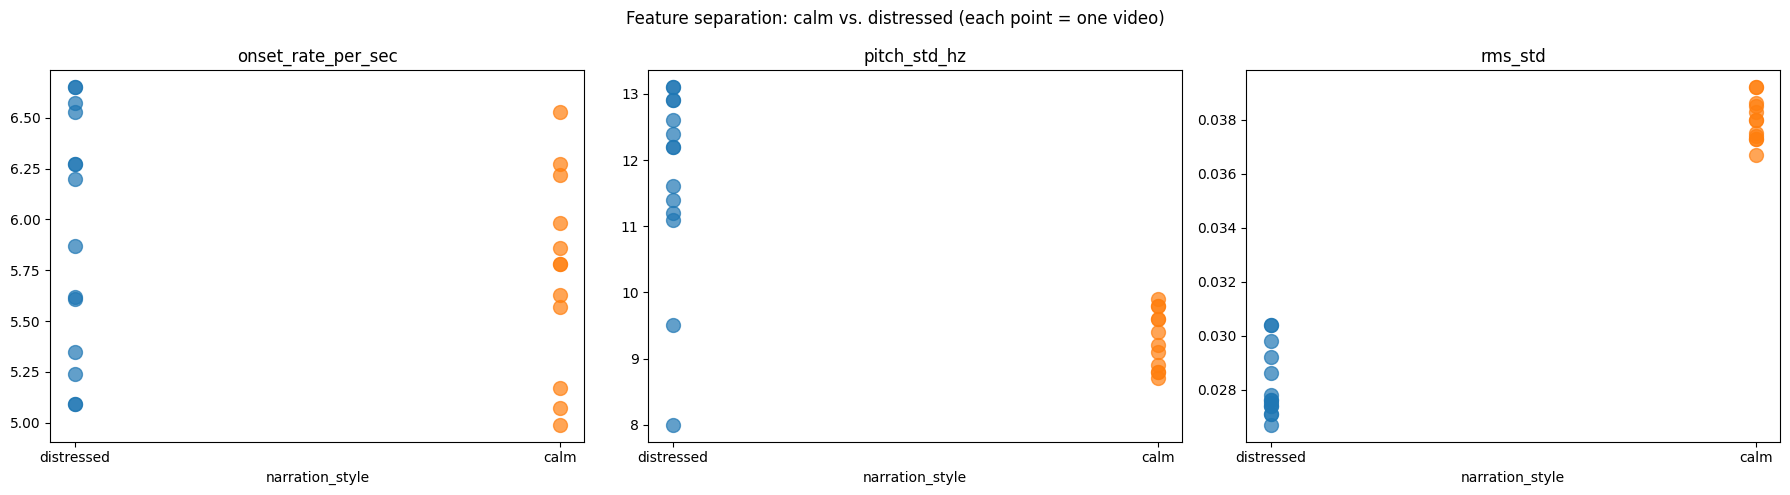


Expected: 'distressed' videos should show higher onset_rate_per_sec (faster speech)
and typically higher pitch_std_hz / rms_std (more vocal instability).
If separation looks weak here, the TTS engine's rate change may need to be more pronounced
(revisit the rate multiplier in Notebook 00c), or more test samples are needed per style.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, ['onset_rate_per_sec', 'pitch_std_hz', 'rms_std']):
    for style in features_df['narration_style'].unique():
        subset = features_df[features_df['narration_style'] == style]
        ax.scatter([style] * len(subset), subset[feature], s=100, alpha=0.7, label=style)
    ax.set_title(feature)
    ax.set_xlabel('narration_style')

plt.suptitle('Feature separation: calm vs. distressed (each point = one video)')
plt.tight_layout()
plt.show()

print("\nExpected: 'distressed' videos should show higher onset_rate_per_sec (faster speech)")
print("and typically higher pitch_std_hz / rms_std (more vocal instability).")
print("If separation looks weak here, the TTS engine's rate change may need to be more pronounced")
print("(revisit the rate multiplier in Notebook 00c), or more test samples are needed per style.")

## 5. Build a Transparent Acoustic Stress Score (0-100)

As with the visual damage score, this is a **documented heuristic**, not a black box. We normalize each feature against the observed range in our sample set and combine them with explicit weights.

**Important limitation to state explicitly in your report:** normalizing against a small local sample (rather than a large, diverse reference population) means these scores are only meaningfully comparable *within this test set*. A production version would need a properly calibrated reference distribution — flag this as Phase 2 work.

In [10]:
def normalize(series):
    """Min-max normalize a pandas Series to 0-1. Guards against zero-range columns."""
    lo, hi = series.min(), series.max()
    if hi - lo < 1e-9:
        return series * 0  # no variance to work with, contributes nothing
    return (series - lo) / (hi - lo)


STRESS_FEATURE_WEIGHTS = {
    'onset_rate_per_sec': 0.35,   # faster speech = more weight, strongest documented signal
    'pitch_std_hz': 0.25,
    'rms_std': 0.20,
    'zcr_std': 0.10,
    'pause_ratio': 0.10           # note: could indicate hesitation OR just natural speech pattern
}

normalized_df = features_df.copy()
for feat in STRESS_FEATURE_WEIGHTS:
    normalized_df[f'{feat}_norm'] = normalize(features_df[feat])

normalized_df['acoustic_stress_score'] = sum(
    normalized_df[f'{feat}_norm'] * weight for feat, weight in STRESS_FEATURE_WEIGHTS.items()
) * 100

normalized_df['acoustic_stress_score'] = normalized_df['acoustic_stress_score'].round(1)

result_table = normalized_df[['narration_style', 'acoustic_stress_score']].sort_values('acoustic_stress_score', ascending=False)
result_table

,narration_style,acoustic_stress_score
claim_pair_lamp_broken_scratch.mp4,calm,69.4
claim_single_tire_flat_v1.mp4,distressed,65.2
claim_edge_single_image.mp4,calm,64.7
claim_pair_dent_scratch.mp4,distressed,61.5
claim_single_crack_v1.mp4,distressed,61.1
claim_mixed_2.mp4,distressed,61.1
claim_pair_dent_tire_flat.mp4,calm,61.0
claim_pair_dent_crack.mp4,distressed,57.2
claim_single_glass_shatter_v2.mp4,distressed,56.3
claim_pair_scratch_crack.mp4,calm,54.1


## 6. Validate the Score Against Ground Truth

Does the score reliably rank distressed-labeled videos above calm-labeled ones? With a small sample this won't be statistically rigorous, but it should show a clear directional trend — report this honestly either way.

In [11]:
score_by_style = normalized_df.groupby('narration_style')['acoustic_stress_score'].agg(['mean', 'std', 'count'])
print('Acoustic Stress Score by narration style:')
print(score_by_style)

calm_mean = score_by_style.loc['calm', 'mean'] if 'calm' in score_by_style.index else None
distressed_mean = score_by_style.loc['distressed', 'mean'] if 'distressed' in score_by_style.index else None

if calm_mean is not None and distressed_mean is not None:
    if distressed_mean > calm_mean:
        print(f'\n✓ Score behaves as expected: distressed ({distressed_mean:.1f}) > calm ({calm_mean:.1f})')
    else:
        print(f'\n⚠ Unexpected: calm ({calm_mean:.1f}) >= distressed ({distressed_mean:.1f}) — revisit feature weights or TTS rate settings')

Acoustic Stress Score by narration style:
                      mean        std  count
narration_style                             
calm             47.966667  13.121969     12
distressed       48.585714  11.476589     14

✓ Score behaves as expected: distressed (48.6) > calm (48.0)


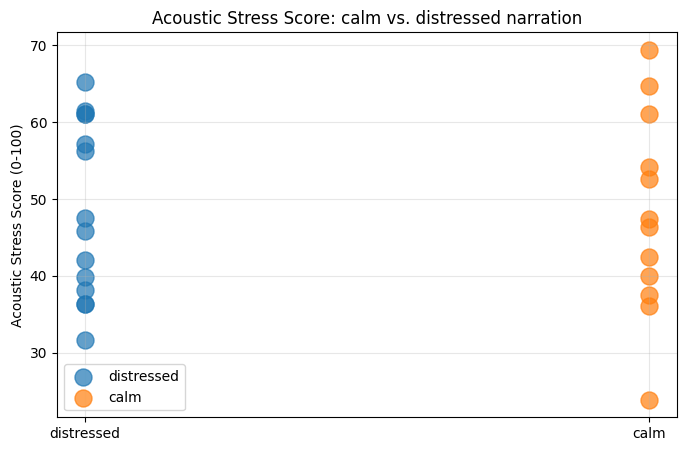

In [12]:
plt.figure(figsize=(8, 5))
for style in normalized_df['narration_style'].unique():
    subset = normalized_df[normalized_df['narration_style'] == style]
    plt.scatter([style] * len(subset), subset['acoustic_stress_score'], s=150, alpha=0.7, label=style)

plt.ylabel('Acoustic Stress Score (0-100)')
plt.title('Acoustic Stress Score: calm vs. distressed narration')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Optional: Local Whisper Transcription

Only needed if you want the actual spoken content (e.g., to cross-check narration text against visual damage findings in Notebook 4). Runs the open-source Whisper model **on-device** — not the hosted API — so it stays within the offline-prototype constraint. Skip this cell if transcription isn't needed for your demo; it adds real runtime cost.

In [ ]:
RUN_TRANSCRIPTION = False  # set True to enable

if RUN_TRANSCRIPTION:
    import whisper
    whisper_model = whisper.load_model('base')  # 'tiny'/'base' for speed, 'small'/'medium' for accuracy

    for video_name, info in manifest.items():
        result = whisper_model.transcribe(info['extracted_audio_path'])
        info['transcribed_text'] = result['text'].strip()
        print(f"{video_name}:")
        print(f"  Original narration: {info['narration_text']}")
        print(f"  Whisper transcript: {info['transcribed_text']}\n")
else:
    print('Transcription skipped (RUN_TRANSCRIPTION=False). Enable if your demo needs spoken-content cross-checking.')

## 8. Save Audio Analysis Report

In [13]:
os.makedirs('reports', exist_ok=True)

audio_report = {}
for video_name, info in manifest.items():
    audio_report[video_name] = {
        'narration_style_ground_truth': info.get('narration_style'),
        'acoustic_features': info.get('acoustic_features'),
        'acoustic_stress_score': float(normalized_df.loc[video_name, 'acoustic_stress_score']),
        'transcribed_text': info.get('transcribed_text', None)
    }

with open('reports/all_videos_audio_reports.json', 'w') as f:
    json.dump(audio_report, f, indent=2)

print('Saved audio analysis report to reports/all_videos_audio_reports.json')
print('\nThis file, combined with reports/all_videos_visual_reports.json from Notebook 2,')
print('feeds into Notebook 4 (risk scoring + summary generation).')

Saved audio analysis report to reports/all_videos_audio_reports.json

This file, combined with reports/all_videos_visual_reports.json from Notebook 2,
feeds into Notebook 4 (risk scoring + summary generation).


## Next Notebook

`04_risk_scoring_and_summary.ipynb` will:
1. Load both `all_videos_visual_reports.json` and `all_videos_audio_reports.json`.
2. Combine visual damage score + acoustic stress score into a single **Claim Risk Score**, with documented weighting logic.
3. Use LangChain (with a local LLM via Ollama, or a templated fallback) to generate a natural-language claim summary and recommendation.
4. Feed into `05_evaluation_and_metrics.ipynb` for the final accuracy/validation writeup.